<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Stochastic-modeling-and-derivatives---TD3" data-toc-modified-id="Stochastic-modeling-and-derivatives---TD3-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Stochastic modeling and derivatives - TD3</a></span><ul class="toc-item"><li><span><a href="#Exercice:-Pricing-d'options-américaines-dans-le-modèle-binomial" data-toc-modified-id="Exercice:-Pricing-d'options-américaines-dans-le-modèle-binomial-1.1"><span class="toc-item-num">1.1&nbsp;&nbsp;</span>Exercice: Pricing d'options américaines dans le modèle binomial</a></span><ul class="toc-item"><li><span><a href="#Implémentation-de-l'équation-rétrograde-américaine" data-toc-modified-id="Implémentation-de-l'équation-rétrograde-américaine-1.1.1"><span class="toc-item-num">1.1.1&nbsp;&nbsp;</span>Implémentation de l'équation rétrograde américaine</a></span></li><li><span><a href="#Le-cas-du-call" data-toc-modified-id="Le-cas-du-call-1.1.2"><span class="toc-item-num">1.1.2&nbsp;&nbsp;</span>Le cas du call</a></span></li><li><span><a href="#Le-cas-du-put" data-toc-modified-id="Le-cas-du-put-1.1.3"><span class="toc-item-num">1.1.3&nbsp;&nbsp;</span>Le cas du put</a></span></li></ul></li></ul></li></ul></div>

# Stochastic modeling and derivatives - TD3

In [2]:
import numpy as np
import matplotlib.pyplot as plt

## Exercice: Pricing d'options américaines dans le modèle binomial

$\bullet$ $P_{t_i} = $ prix d'une option américaine de maturité $t_n$ et de payoff $\Psi(\cdot)$ dans le modèle binomial 

$\bullet$ Equation de programmation dynamique
$$
\begin{aligned}
&P_{t_n} = \Psi(S_{t_n})
\\
&P_{t_i} = \max \left( \Psi(S_{t_i}), \, \mathbb{E}^{\mathbb{Q}} \Bigl[ \frac 1{1+r} P_{t_{i+1}} \Big| S_{t_i} \Bigr] \right),
\qquad i = 0, 1, \dotsm n-1,
\end{aligned}
$$

où $\mathbb{Q}$ est la mesure risque-neutre du modèle binomial.

$\bullet$ Alternativement, on peut écrire l'équation de programmation dynamique directement pour la fonction de prix de l'option $v_{\mathrm{Am}}(t_i, \cdot)$:

\begin{equation}
\begin{aligned} 
&v_{\mathrm{Am}}(t_n, S) = \Psi(S)
\\
&v_{\mathrm{Am}}(t_i, S) = \max \left( \Psi(S), \frac 1{1+r} \Bigl( v_{\mathrm{Am}}(t_{i+1}, S \, u) \, q^{\mathrm{up}} + v_{\mathrm{Am}}(t_{i+1}, S \, d) \, q^{\mathrm{down}} \Bigr) \right),
\qquad i = 0, 1, \dotsm n-1.
\end{aligned}
\end{equation}

On remarquera que l'on a remplacé l'espérance conditionnelle $\mathbb{E}^{\mathbb{Q}} \Bigl[ \frac 1{1+r} P_{t_{i+1}} \Big| S_{t_i} \Bigr]$ par son expression explicite dans le modèle binomial (faisant apparaitre $q^{\mathrm{up}}, q^{\mathrm{down}}$).

$\bullet$ Remarque: l'équation ci-dessus a la même nature que la récursion pour l'option européenne (TP2). La seule différence est que, maintenant, on prend à chaque date le $\max$ entre l'actualisation de $v_{\mathrm{Am}}(t_{i+1}, \cdot)$ et le payoff $\Psi$.

### Implémentation de l'équation rétrograde américaine

Nous travaillons sur l'équation de programmation dynamique pour la fonction $v_{\mathrm{Am}}$.

$\bullet$ Comme dans le cas de l'option européenne, on veut créer une fonction Python qui effectue l'itération pour l'option américaine de l'étape $i+1$ à l'étape $i$:

In [3]:
def recursion_americaine(r, u, d, payoff, fonction_prix_t_i_plus_one, delta_flag=False):
    """
    On effectue une itération dans l'équation de programmation dynamique de la date t_{i+1} à la date t_i.
    
    Paramètres
    + r, u, d: les paramètres du modèle binomial 
    
    + payoff (fonction Python): la fonction payoff de l'opt américaine
    
    + fonction_prix_t_i_plus_one (fonction Python): la fonction de prix v_{Am}(t_{i+1}, .) de l'opt américaine à la date t_{i+1}.
      Cette fonction doit prendre comme argument la valeur S_{t_{i+1}} du sous-jacent.
    
    Output: une fonction Python, la fonction de prix v_{Am}(t_i, .) de l'opt américaine à la date t_i.
            Cette fonction prendra comme argument la valeur S_{t_i} du sous-jacent.
    """
    q_up = (1 + r - d) / (u-d)
    q_down = 1 - q_up
    
    def fonction_prix_t_i(S):
        ########################################################
        ## TO DO: compléter avec l'itération de t_{i+1} à t_i
        ########################################################
       
        valeur_continuation = (q_up * fonction_prix_t_i_plus_one(u * S) + q_down * fonction_prix_t_i_plus_one(d * S)) / (1 + r)
        valeur_exercise = payoff(S)
        valeur = np.maximum(valeur_exercise , valeur_continuation)
        
        return valeur
    
    if delta_flag:
      def delta_t_i(S):
          delta = (fonction_prix_t_i_plus_one(S*u) - fonction_prix_t_i_plus_one(S*d)) / (S*(u - d))
          return delta

    if delta_flag == 0:
      return fonction_prix_t_i
    else:
        return fonction_prix_t_i, delta_t_i

$\bullet$ Ensuite, on procède de manière rétrograde pour calculer le prix en $t_i$ pour $0 \le i < n$ de l'option américaine de payoff $\Psi(.)$ et maturité $t_n$.

In [4]:
def prix_americain_t_i(r, u, d, payoff, i, n, delta_flag=False):
    """
    Prix à la date t_i, i < n, de l'option américaine de maturité t_n et de fct de payoff donnée.
    
    Output: une fonction Python, la fonction de prix v_{Am}(t_i, .) à la date t_i.
            Cette fonction prendra comme argument la valeur S_{t_i} du sous-jacent.
    """
    fonction_prix = payoff
    
    ## Attention à l'itération sur l'objet "range":
    ## range(n, i, -1) contient les entiers ordonnés de n à i+1
    for j in range(n, i, -1):
        
        ########################################################
        ## TO DO: compléter avec le calcul de la fonction de prix
        ## à la date t_i
        ########################################################
        fonction_prix, fonction_delta = recursion_americaine(r, u, d, payoff, fonction_prix, delta_flag=True)
    if delta_flag:
        return fonction_prix, fonction_delta
    else:
        return fonction_prix

### Le cas du call

$\bullet$ Comparer le résultats pour l'option européenne et l'option américaine dans le cas du payoff du call $\Psi(S) = (S - K)^+$.

In [ ]:
i = 0
n = 1
S_0 = 100
K = 99.45
r = 0.001
u_percent = 5.0
d_percent = 5.0
p = 3


u = 1 + u_percent / 100
d = 1 - d_percent / 100

assert(d < 1 + r < u)

def payoff_call(S, strike = K):
    return np.maximum(S - strike, 0)

########################################################
## TO DO: compléter avec les calculs des prix 
## européen et américain
########################################################

from opt_europeenne_mod_binomial import recursion, recursion_n_i

## Prix européen
fonction_prix_eur, fonction_delta_eur = recursion_n_i(r, u, d, payoff_call, i, n, True)

prix_eur = fonction_prix_eur(S_0)
delta_eur = fonction_delta_eur(S_0)

## Prix américain
fonction_prix_am, fonction_delta_am = prix_americain_t_i(r, u, d, payoff_call, i, n, True)

prix_am = fonction_prix_am(S_0)
delta_am = fonction_delta_am(S_0)


def payoff_put(S, strike = K):
    return np.maximum(strike - S, 0)

## Prix européen
fonction_prix_eur, fonction_delta_eur = recursion_n_i(r, u, d, payoff_put, i, n, True)

prix_put_eur = fonction_prix_eur(S_0)
delta_put_eur = fonction_delta_eur(S_0)

## Prix américain
fonction_prix_am, fonction_delta_am = prix_americain_t_i(r, u, d, payoff_put, i, n, True)

prix_put_am = fonction_prix_am(S_0)
delta_put_am = fonction_delta_am(S_0)

def payoff_complex(S, strike = K, power = p):
    return np.maximum(np.power(S, power) - strike, 0)

fonction_prix_eur, fonction_delta_eur = recursion_n_i(r, u, d, payoff_complex, i, n, True)
complex_eur = fonction_prix_eur(S_0)
complex_delta_eur = fonction_delta_eur(S_0)

fonction_prix_am, fonction_delta_am = prix_americain_t_i(r, u, d, payoff_complex, i, n, True)

complex_am = fonction_prix_am(S_0)
complex_delta_am = fonction_delta_am(S_0)

def payoff_log(S, initial = S_0):
    return np.log(S / initial)

fonction_prix_eur, fonction_delta_eur = recursion_n_i(r, u, d, payoff_log, i, n, True)
log_eur = fonction_prix_eur(S_0)
log_delta_eur = fonction_delta_eur(S_0)

fonction_prix_am, fonction_delta_am = prix_americain_t_i(r, u, d, payoff_log, i, n, True)

log_am = fonction_prix_am(S_0)
log_delta_am = fonction_delta_am(S_0)


def payoff_power(S, power=p):
    return np.power(S, power)

fonction_prix_eur, fonction_delta_eur = recursion_n_i(r, u, d, payoff_power, i, n, True)
power_eur = fonction_prix_eur(S_0)
power_delta_eur = fonction_delta_eur(S_0)

fonction_prix_am, fonction_delta_am = prix_americain_t_i(r, u, d, payoff_power, i, n, True)

power_am = fonction_prix_am(S_0)
power_delta_am = fonction_delta_am(S_0)

import pandas as pd
pd.set_option("display.float_format", "{:.6f}".format)

pd.DataFrame(data=[[prix_eur, delta_eur], [prix_put_eur, delta_put_eur], [prix_am, delta_am], [prix_put_am, delta_put_am], [complex_eur, complex_delta_eur], [complex_am, complex_delta_am], [log_eur, log_delta_eur], [log_am, log_delta_am], [power_eur, power_delta_eur], [power_am, power_delta_am]],columns=['Price', 'Delta'], index=['European Call', 'European Put', 'American Call', 'American Put', 'European Complex Payoff', 'American Complex Payoff', 'European Log', 'American Log', 'European Power', 'American Power'])

,Price,Delta
European Call,17.282726,0.639098
European Put,10.823833,-0.360902
American Call,17.282726,0.639098
American Put,11.836154,-0.400777
European Complex Payoff,1679339.454695,48623.625657
American Complex Payoff,1679339.454695,48623.625657
European Log,0.001784,0.009457
American Log,0.006358,0.009684
European Power,1679432.025802,48623.625657
American Power,1679432.025802,48623.625657


Vos résultats sont-ils conformes à la théorie?

### Le cas du put

$\bullet$ Même test dans le cas du payoff du put $\Psi(S) = (K - S)^+$: comparer les prix de l'option européenne et de l'option américaine.

In [ ]:
n = 13
i = 0

def payoff_put(S):
    return np.maximum(K - S, 0)

########################################################
## TO DO: compléter avec les calculs des prix 
## européen et américain
########################################################

## Prix européen
fonction_prix_eur, fonction_delta_eur = recursion_n_i(r, u, d, payoff_put, i, n, True)

prix_eur = fonction_prix_eur(S_0)
delta_eur = fonction_delta_eur(S_0)

## Prix américain
fonction_prix_am, fonction_delta_am = prix_americain_t_i(r, u, d, payoff_put, i, n, True)

prix_am = fonction_prix_am(S_0)
delta_am = fonction_delta_am(S_0)

print("Prix en t_%1.0f du put europeen de payoff (S_{t_%1.0f} - %1.1f)^+ lorsque S_{t_%1.0f} = %1.1f: %1.2f" %(i, n, K, i, S_0, prix_eur))
print("Delta en t_%1.0f du put europeen de payoff (S_{t_%1.0f} - %1.1f)^+ lorsque S_{t_%1.0f} = %1.1f: %1.2f" %(i, n, K, i, S_0, delta_eur))

print("Prix en t_%1.0f du put americain de payoff (S_{t_%1.0f} - %1.1f)^+ lorsque S_{t_%1.0f} = %1.1f: %1.2f" %(i, n, K, i, S_0, prix_am))
print("Delta en t_%1.0f du put americain de payoff (S_{t_%1.0f} - %1.1f)^+ lorsque S_{t_%1.0f} = %1.1f: %1.2f" %(i, n, K, i, S_0, delta_am))


Prix en t_0 du put europeen de payoff (S_{t_5} - 100.4)^+ lorsque S_{t_0} = 100.4: 8.78
Delta en t_0 du put europeen de payoff (S_{t_5} - 100.4)^+ lorsque S_{t_0} = 100.4: -0.38
Prix en t_0 du put americain de payoff (S_{t_5} - 100.4)^+ lorsque S_{t_0} = 100.4: 9.19
Delta en t_0 du put americain de payoff (S_{t_5} - 100.4)^+ lorsque S_{t_0} = 100.4: -0.40


$\bullet$ On peut afficher, en fonction de la valeur du sous-jacent $S_0$, le prix du put européen et du put américain de strike $K$ donné.

In [7]:
## Une grille de 100 valeurs du sous-jacent S_0 entre K/3 et 2*K
nb_points = 100
spots = np.linspace(K/3, 2*K, nb_points)

put_prices_eur = np.zeros(nb_points)
put_prices_am = np.zeros(nb_points)

put_delta_eur = np.zeros(nb_points)
put_delta_am = np.zeros(nb_points)

## Les fonctions de prix du put européen et du put américain 
## de strike K = 120 ont déjà été définies plus haut    

for j, S in enumerate(spots):
    ########################################################
    ## TO DO: compléter avec les calculs des prix 
    ## européen et américain
    ########################################################
    put_prices_eur[j] = fonction_prix_eur(S)
    put_delta_eur[j] = fonction_delta_eur(S)
    
    put_prices_am[j] = fonction_prix_am(S)
    put_delta_am[j] = fonction_delta_am(S)

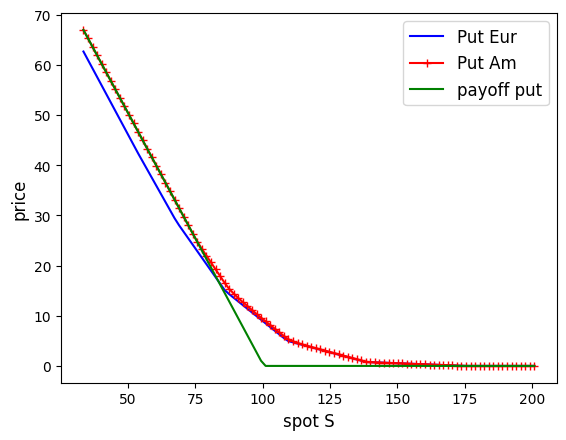

In [8]:
########################################################
## TO DO: compléter avec l'affichage des prix européen
## et américain en fonction des valeurs du spot
########################################################
plt.plot(spots, put_prices_eur, color="b", label="Put Eur")
plt.plot(spots, put_prices_am, color="r", marker="+", label="Put Am")

## On affiche le payoff
plt.plot(spots, payoff_put(spots), color="g", label="payoff put")

plt.xlabel("spot S", fontsize=12)
plt.ylabel("price", fontsize=12)

plt.legend(loc="best", fontsize=12)

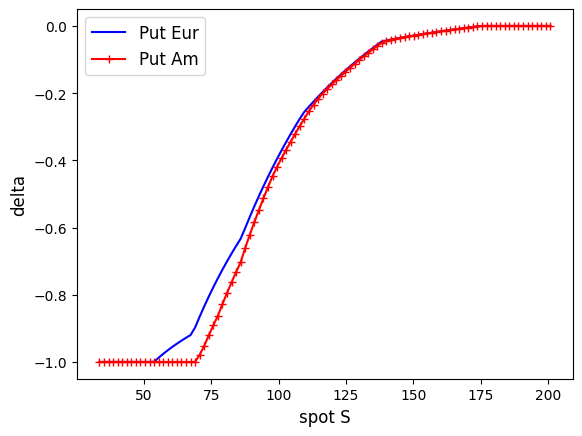

In [9]:
########################################################
## TO DO: compléter avec l'affichage des delta européen
## et américain en fonction des valeurs du spot
########################################################
plt.plot(spots, put_delta_eur, color="b", label="Put Eur")
plt.plot(spots, put_delta_am, color="r", marker="+", label="Put Am")

## On affiche le payoff

plt.xlabel("spot S", fontsize=12)
plt.ylabel("delta", fontsize=12)

plt.legend(loc="best", fontsize=12)

0


C:\Users\lione\AppData\Local\Temp\ipykernel_45540\2764360720.py:32: RuntimeWarning: invalid value encountered in divide
  delta = (fonction_prix_t_i_plus_one(S*u) - fonction_prix_t_i_plus_one(S*d)) / (S*(u - d))


1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


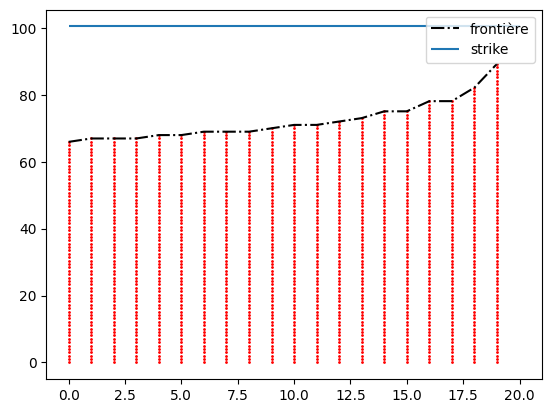

In [10]:
n=20
frontiere_exercice=[]
grille_spot_exercice = np.linspace(0, K, 100) # on n'exerce jamais au dessus du strike car le payoff est nul
for i in range(n):
    print(i)
    fonction_prix_am, fonction_delta_am = prix_americain_t_i(r, u, d, payoff_put, i, n, True)

    prix_am = fonction_prix_am(grille_spot_exercice)
    delta_am = fonction_delta_am(grille_spot_exercice)
    payoffs = payoff_put(grille_spot_exercice)
    spot_region_exercice=grille_spot_exercice[prix_am==payoffs]

    frontiere_exercice.append(np.max(spot_region_exercice))
    plt.scatter(np.zeros(spot_region_exercice.size)+i, spot_region_exercice, color="red", marker="o" , s=1)
plt.plot(range(n), frontiere_exercice, label="frontière", color="black", ls="-.")
plt.hlines(y=K, xmin=0, xmax=n, label='strike')
_=plt.legend()